Librerias

In [ ]:
!pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn pillow imagehash kaggle jupyter ipykernel

^C



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import os
import imagehash
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from procesamiento import dividir_train_val_test, calcular_hash, marcar_duplicado_verificado, son_realmente_duplicados
from sklearn.preprocessing import LabelEncoder




Cosas necesarias para tener el  train test

In [13]:
N_POR_CLASE = 600
SEMILLA = 42
TAM_OBJETIVO = (64, 64)
np.random.seed(SEMILLA)


RUTA_DATASET = r"archive/asl_alphabet_train/asl_alphabet_train"

datos_img = []

for clase in sorted(os.listdir(RUTA_DATASET)):
    carpeta = os.path.join(RUTA_DATASET, clase)
    if not os.path.isdir(carpeta):
        continue

    for archivo in os.listdir(carpeta):
        ruta = os.path.join(carpeta, archivo)
        try:
            imagen = Image.open(ruta)
            ancho, alto = imagen.size
            datos_img.append({
                "clase": clase,
                "archivo": archivo,
                "ruta": ruta,
                "ancho": ancho,
                "alto": alto,
                "modo": imagen.mode,
                "formato": imagen.format
            })
        except Exception as e:
            print(f"No se pudo abrir {ruta}")

datos_img = pd.DataFrame(datos_img)

print("Cantidad total de imágenes:")
print(len(datos_img))

datos_img.head()



partes = []
for clase, grupo in datos_img.groupby("clase"):
    n = min(N_POR_CLASE, len(grupo))
    partes.append(grupo.sample(n=n, random_state=SEMILLA))

submuestra = pd.concat(partes).reset_index(drop=True)


submuestra["phash"] = submuestra["ruta"].apply(lambda r: calcular_hash(r, hash_size=16))


Cantidad total de imágenes:
87000


duplicados y transformaciones

In [14]:
def cargar_y_preprocesar(df, tam=TAM_OBJETIVO):
    """Carga imágenes desde 'ruta', redimensiona y normaliza a [0, 1]."""
    imagenes = []
    for ruta in df["ruta"]:
        img = Image.open(ruta).convert("RGB").resize(tam)
        arr = np.array(img, dtype=np.float32) / 255.0
        imagenes.append(arr)
    X = np.stack(imagenes)
    y = df["clase"].values
    return X, y

duplicados = submuestra[submuestra.duplicated(subset="phash", keep=False)]
print(f"\nImágenes con hash repetido: {len(duplicados)} de {len(submuestra)}")

indices_duplicados_reales = []
for phash_val, grupo in duplicados.groupby("phash"):
    indices_duplicados_reales.extend(marcar_duplicado_verificado(grupo))

submuestra_limpia = submuestra.drop(index=indices_duplicados_reales).reset_index(drop=True)
print(f"Duplicados confirmados y eliminados: {len(indices_duplicados_reales)}")
print(f"Submuestra final: {len(submuestra_limpia)} imágenes")

# Verificar que la limpieza no haya desbalanceado alguna clase
print("\nDistribución de clases tras limpieza:")
print(submuestra_limpia["clase"].value_counts().sort_values())


#SPLIT TRAIN / VAL / TEST (70/15/15, estratificado)
train_df, val_df, test_df = dividir_train_val_test(
    df=submuestra_limpia,
    col_clase="clase",
    semilla=SEMILLA
)


# PREPROCESAMIENTO FINAL: resize + normalización -> arrays listos para modelar
X_train, y_train_raw = cargar_y_preprocesar(train_df)
X_val, y_val_raw = cargar_y_preprocesar(val_df)
X_test, y_test_raw = cargar_y_preprocesar(test_df)

# Codificación de etiquetas (texto -> enteros); se ajusta SOLO con train
codificador = LabelEncoder()
codificador.fit(y_train_raw)

y_train = codificador.transform(y_train_raw)
y_val = codificador.transform(y_val_raw)
y_test = codificador.transform(y_test_raw)

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"Rango de X_train tras normalizar: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Clases codificadas: {dict(zip(codificador.classes_, range(len(codificador.classes_))))}")



Imágenes con hash repetido: 22 de 17400
Duplicados confirmados y eliminados: 9
Submuestra final: 17391 imágenes

Distribución de clases tras limpieza:
clase
M          599
O          599
U          599
Y          599
B          599
E          599
I          599
space      599
K          599
A          600
D          600
C          600
G          600
H          600
J          600
F          600
W          600
V          600
T          600
S          600
R          600
Q          600
P          600
N          600
L          600
Z          600
del        600
nothing    600
X          600
Name: count, dtype: int64
Train: 12173 (70.0%) | Val: 2609 (15.0%) | Test: 2609 (15.0%)

X_train: (12173, 64, 64, 3), y_train: (12173,)
X_val:   (2609, 64, 64, 3), y_val:   (2609,)
X_test:  (2609, 64, 64, 3), y_test:  (2609,)
Rango de X_train tras normalizar: [0.00, 1.00]
Clases codificadas: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 1

In [ ]:

# LIBRERÍAS
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
 
SEMILLA = 42
tf.random.set_seed(SEMILLA)
np.random.seed(SEMILLA)
 
NUM_CLASES = len(codificador.classes_)
NOMBRES_CLASES = list(codificador.classes_)
INPUT_SHAPE = X_train.shape[1:]  # (64, 64, 3)
 
print(f"Número de clases: {NUM_CLASES}")
print(f"Shape de entrada: {INPUT_SHAPE}")
 
 
# Función auxiliar: entrenar, evaluar y graficar
def entrenar_y_evaluar(modelo, nombre, X_train, y_train, X_val, y_val, X_test, y_test,
                        epochs=15, batch_size=32, verbose=1):
    """
    Entrena un modelo de Keras y devuelve un diccionario con las métricas
    relevantes para comparar arquitecturas (accuracy, loss, tiempo, etc.).
    También grafica curvas de entrenamiento y matriz de confusión.
    """
    print(f"\n{'='*60}")
    print(f"Entrenando modelo: {nombre}")
    print(f"{'='*60}")
    modelo.summary()
 
    inicio = time.time()
    historia = modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose
    )
    tiempo_entrenamiento = time.time() - inicio
 
    # Evaluación en validación y test
    val_loss, val_acc = modelo.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = modelo.evaluate(X_test, y_test, verbose=0)
 
    # Predicciones para matriz de confusión y reporte
    y_pred_prob = modelo.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
 
    # --- Curvas de accuracy y loss ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(historia.history["accuracy"], label="Train")
    axes[0].plot(historia.history["val_accuracy"], label="Validation")
    axes[0].set_title(f"{nombre} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
 
    axes[1].plot(historia.history["loss"], label="Train")
    axes[1].plot(historia.history["val_loss"], label="Validation")
    axes[1].set_title(f"{nombre} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
 
    # --- Matriz de confusión ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap="Blues",
                xticklabels=NOMBRES_CLASES, yticklabels=NOMBRES_CLASES)
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()
 
    # --- Reporte de clasificación ---
    print(f"\nReporte de clasificación - {nombre}")
    print(classification_report(y_test, y_pred, target_names=NOMBRES_CLASES))
 
    print(f"Tiempo de entrenamiento: {tiempo_entrenamiento:.1f} segundos")
    print(f"Val accuracy: {val_acc:.4f} | Val loss: {val_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")
 
    return {
        "nombre": nombre,
        "modelo": modelo,
        "historia": historia,
        "tiempo_entrenamiento_seg": tiempo_entrenamiento,
        "val_accuracy": val_acc,
        "val_loss": val_loss,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "num_parametros": modelo.count_params(),
        "epochs": epochs,
        "batch_size": batch_size,
    }
 

Número de clases: 29
Shape de entrada: (64, 64, 3)



Entrenando modelo: Red Neuronal Simple (FC)


Model: "Red_Simple_FC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,430,749 (24.53 MB)

 Trainable params: 6,430,749 (24.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.0403 - loss: 3.5632 - val_accuracy: 0.0544 - val_loss: 3.2860
Epoch 2/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.0491 - loss: 3.2923 - val_accuracy: 0.0609 - val_loss: 3.2287
Epoch 3/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.0550 - loss: 3.2574 - val_accuracy: 0.0544 - val_loss: 3.1721
Epoch 4/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.0547 - loss: 3.2347 - val_accuracy: 0.0682 - val_loss: 3.1416
Epoch 5/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.0526 - loss: 3.2268 - val_accuracy: 0.0663 - val_loss: 3.1152
Epoch 6/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.0558 - loss: 3.2111 - val_accuracy: 0.0724 - val_loss: 3.1041
Epoch 7/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.0536 - loss: 3.2112 - val_accuracy: 0.0671 - val_loss: 3.1432
Epoch 8/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.0550 - loss: 3.1980 - val_accu

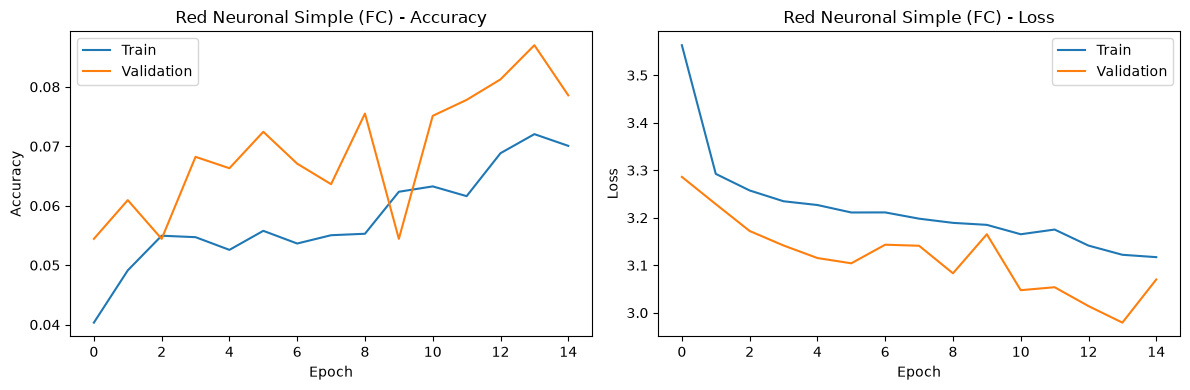

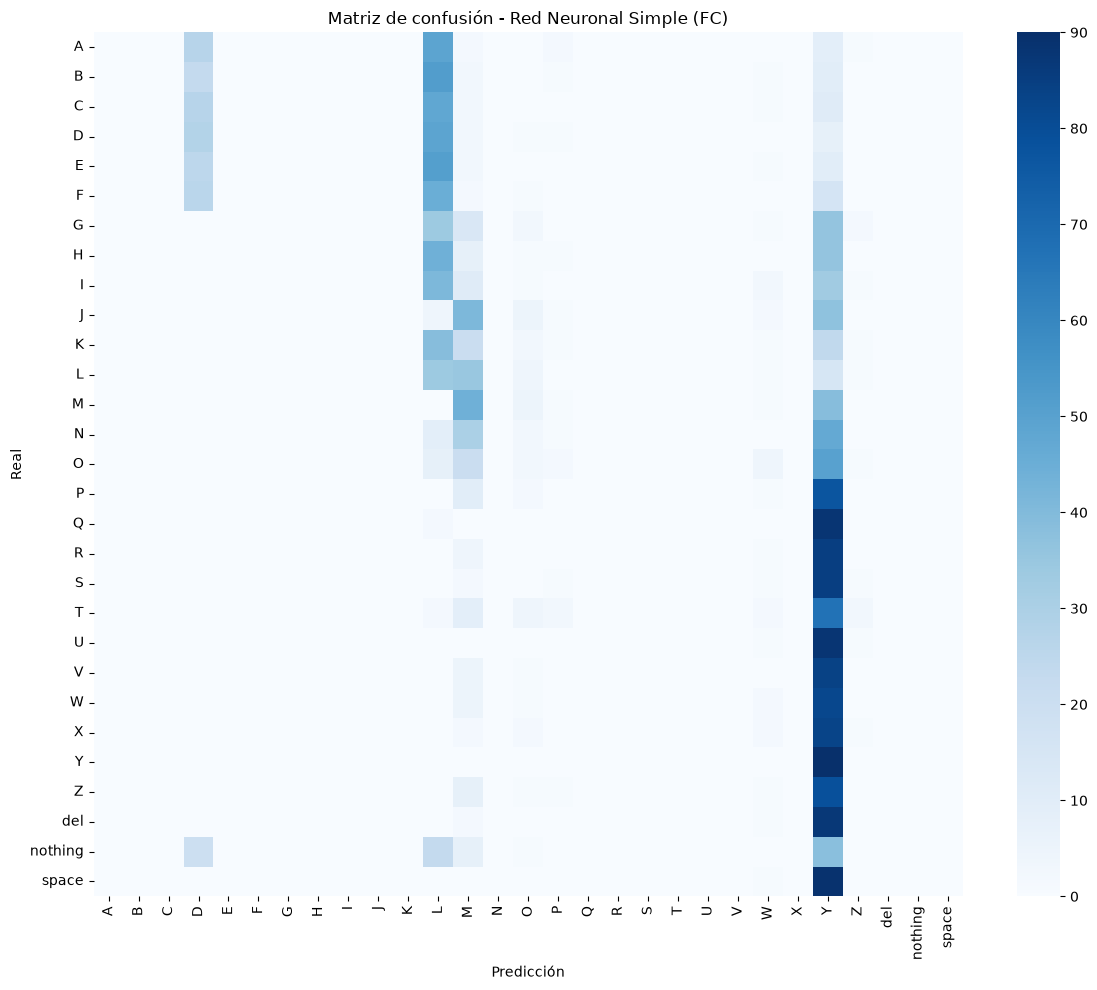


Reporte de clasificación - Red Neuronal Simple (FC)
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        90
           B       0.00      0.00      0.00        90
           C       0.00      0.00      0.00        90
           D       0.16      0.31      0.21        90
           E       0.00      0.00      0.00        90
           F       0.00      0.00      0.00        90
           G       0.00      0.00      0.00        90
           H       0.00      0.00      0.00        90
           I       0.00      0.00      0.00        90
           J       0.00      0.00      0.00        90
           K       0.00      0.00      0.00        90
           L       0.06      0.38      0.11        90
           M       0.15      0.49      0.23        90
           N       0.00      0.00      0.00        90
           O       0.07      0.03      0.05        89
           P       0.00      0.00      0.00        90
           Q       0.00     

c:\Users\darta\OneDrive\Desktop\REN\UVG\2026\Segundo ciclo\Data Science\DataS_Lab3_ASL\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darta\OneDrive\Desktop\REN\UVG\2026\Segundo ciclo\Data Science\DataS_Lab3_ASL\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darta\OneDrive\Desktop\REN\UVG\2026\Segundo ciclo\Data Science\DataS_Lab3_ASL\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0

In [ ]:

# EJERCICIO 5 :
# Red neuronal simple (fully-connected)

def construir_red_simple(input_shape, num_clases):
    modelo = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_clases, activation="softmax"),
    ], name="Red_Simple_FC")
 
    modelo.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo
 
 
modelo_fc = construir_red_simple(INPUT_SHAPE, NUM_CLASES)
resultado_fc = entrenar_y_evaluar(
    modelo_fc, "Red Neuronal Simple (FC)",
    X_train, y_train, X_val, y_val, X_test, y_test,
    epochs=15, batch_size=32
)
 
 
 


Entrenando modelo: CNN 1 (base)


Model: "CNN1_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,413 (8.09 MB)

 Trainable params: 2,120,413 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1896 - loss: 2.8316 - val_accuracy: 0.4760 - val_loss: 1.9212
Epoch 2/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4480 - loss: 1.7360 - val_accuracy: 0.6861 - val_loss: 1.1427
Epoch 3/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5880 - loss: 1.2244 - val_accuracy: 0.7785 - val_loss: 0.8139
Epoch 4/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6831 - loss: 0.9318 - val_accuracy: 0.8260 - val_loss: 0.5941
Epoch 5/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7395 - loss: 0.7632 - val_accuracy: 0.8589 - val_loss: 0.4905
Epoch 6/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7770 - loss: 0.6289 - val_accuracy: 0.8785 - val_loss: 0.4159
Epoch 7/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8065 - loss: 0.5586 - val_accuracy: 0.8961 - val_loss: 0.3621
Epoch 8/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8365 - loss: 0.4698 - val_accu

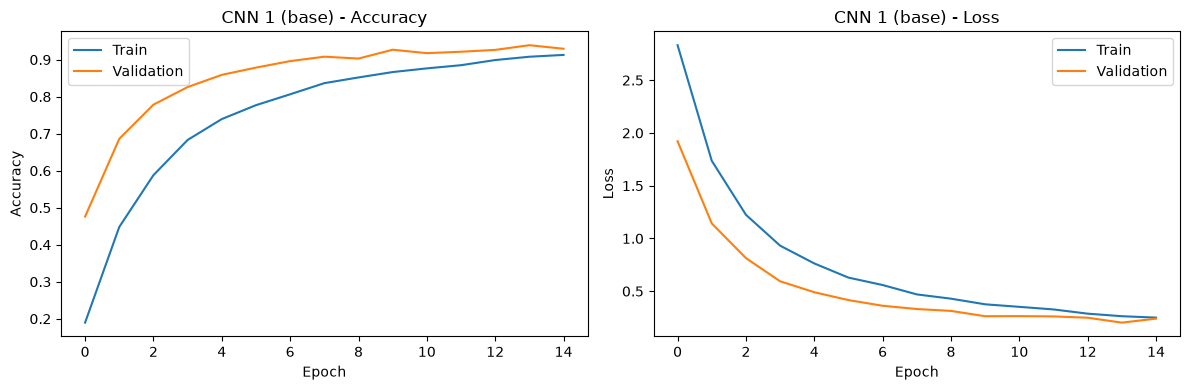

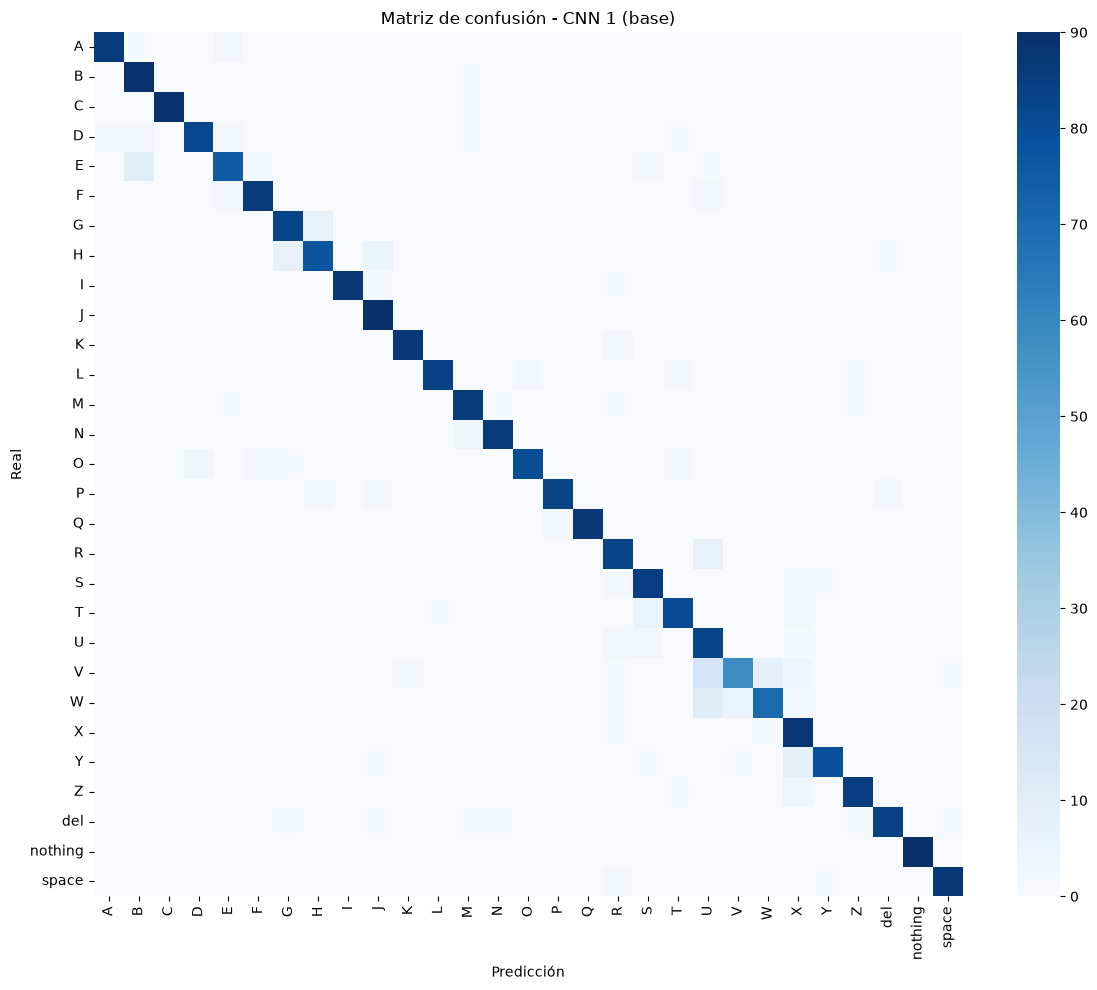


Reporte de clasificación - CNN 1 (base)
              precision    recall  f1-score   support

           A       0.98      0.96      0.97        90
           B       0.87      0.99      0.93        90
           C       1.00      0.99      0.99        90
           D       0.95      0.91      0.93        90
           E       0.90      0.83      0.87        90
           F       0.96      0.96      0.96        90
           G       0.90      0.92      0.91        90
           H       0.90      0.86      0.88        90
           I       1.00      0.97      0.98        90
           J       0.89      1.00      0.94        90
           K       0.98      0.97      0.97        90
           L       0.99      0.93      0.96        90
           M       0.91      0.96      0.93        90
           N       0.98      0.96      0.97        90
           O       0.96      0.90      0.93        89
           P       0.97      0.92      0.94        90
           Q       1.00      0.97      0

In [ ]:

# EJERCICIO 4 - CNN #1: ARQUITECTURA BASE
def construir_cnn1(input_shape, num_clases):
    modelo = models.Sequential([
        layers.Input(shape=input_shape),
 
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
 
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
 
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_clases, activation="softmax"),
    ], name="CNN1_base")
 
    modelo.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo
 
 
modelo_cnn1 = construir_cnn1(INPUT_SHAPE, NUM_CLASES)
resultado_cnn1 = entrenar_y_evaluar(
    modelo_cnn1, "CNN 1 (base)",
    X_train, y_train, X_val, y_val, X_test, y_test,
    epochs=15, batch_size=32
)


--- CNN2, configuración 1: {'dropout': 0.4, 'learning_rate': 0.0005, 'batch_size': 32, 'epochs': 15} ---

Entrenando modelo: CNN2 - config 1


Model: "CNN2_profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,244,285 (8.56 MB)

 Trainable params: 2,244,285 (8.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.2321 - loss: 2.6367 - val_accuracy: 0.6259 - val_loss: 1.3453
Epoch 2/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.6415 - loss: 1.1051 - val_accuracy: 0.8574 - val_loss: 0.4945
Epoch 3/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.8212 - loss: 0.5495 - val_accuracy: 0.9088 - val_loss: 0.3008
Epoch 4/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.8912 - loss: 0.3355 - val_accuracy: 0.9479 - val_loss: 0.1914
Epoch 5/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9238 - loss: 0.2294 - val_accuracy: 0.9521 - val_loss: 0.1539
Epoch 6/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.9404 - loss: 0.1766 - val_accuracy: 0.9709 - val_loss: 0.1071
Epoch 7/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9469 - loss: 0.1568 - val_accuracy: 0.9670 - val_loss: 0.1009
Epoch 8/15
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.9637 - loss: 0.1081 - 

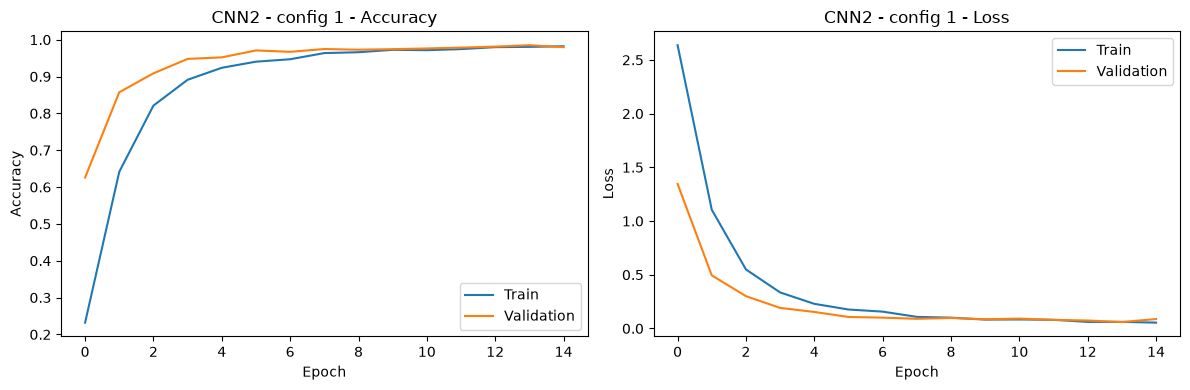

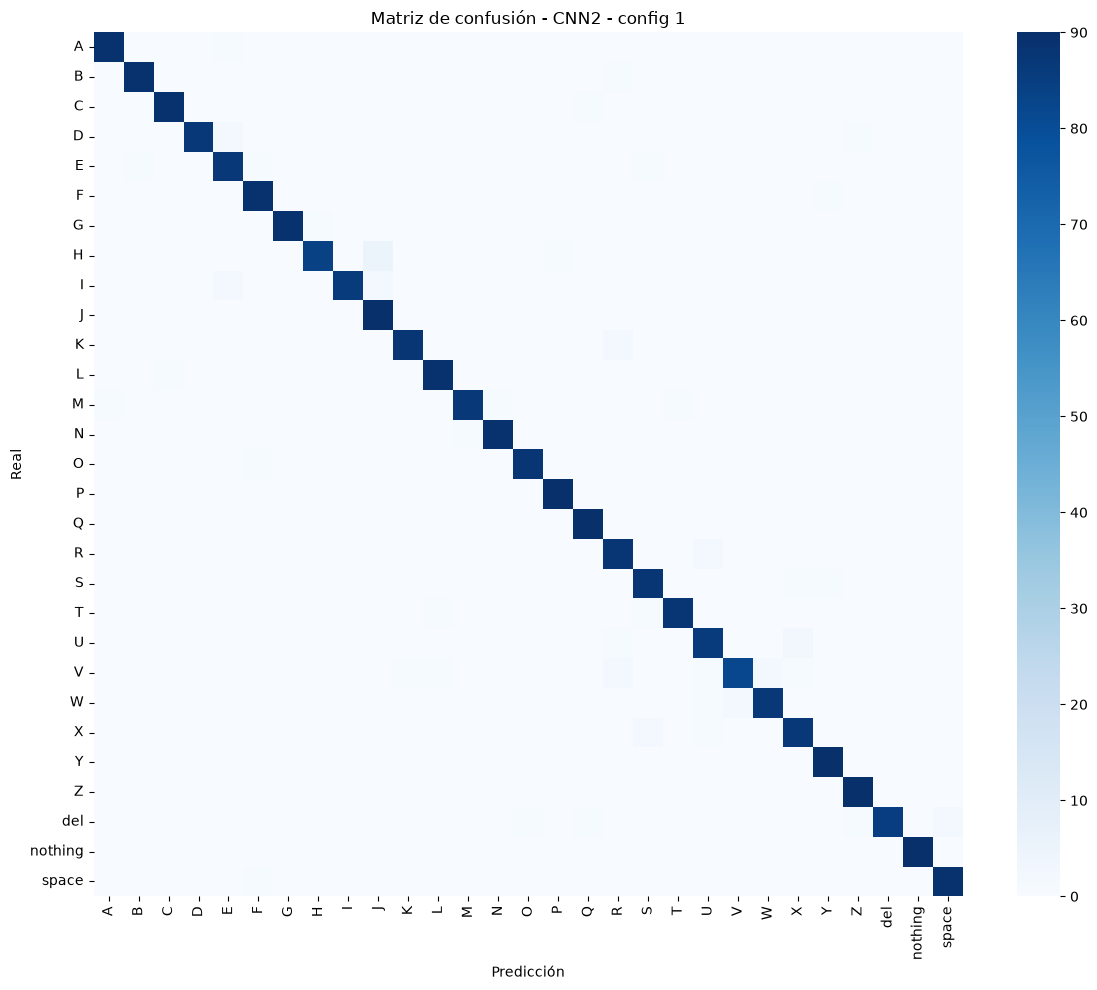


Reporte de clasificación - CNN2 - config 1
              precision    recall  f1-score   support

           A       0.99      0.99      0.99        90
           B       0.99      0.99      0.99        90
           C       0.99      0.99      0.99        90
           D       1.00      0.97      0.98        90
           E       0.95      0.97      0.96        90
           F       0.97      0.99      0.98        90
           G       1.00      0.99      0.99        90
           H       0.99      0.93      0.96        90
           I       1.00      0.96      0.98        90
           J       0.93      1.00      0.96        90
           K       0.99      0.98      0.98        90
           L       0.98      0.99      0.98        90
           M       0.99      0.97      0.98        90
           N       0.99      0.99      0.99        90
           O       0.99      0.99      0.99        89
           P       0.99      1.00      0.99        90
           Q       0.98      1.00    

Model: "CNN2_profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,244,285 (8.56 MB)

 Trainable params: 2,244,285 (8.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - accuracy: 0.2219 - loss: 2.6758 - val_accuracy: 0.5822 - val_loss: 1.4539
Epoch 2/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.6192 - loss: 1.1590 - val_accuracy: 0.8375 - val_loss: 0.5528
Epoch 3/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - accuracy: 0.7984 - loss: 0.6108 - val_accuracy: 0.9011 - val_loss: 0.3277
Epoch 4/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.8659 - loss: 0.3989 - val_accuracy: 0.9352 - val_loss: 0.2113
Epoch 5/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 25s 131ms/step - accuracy: 0.9079 - loss: 0.2678 - val_accuracy: 0.9578 - val_loss: 0.1617
Epoch 6/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - accuracy: 0.9321 - loss: 0.1955 - val_accuracy: 0.9578 - val_loss: 0.1290
Epoch 7/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.9412 - loss: 0.1773 - val_accuracy: 0.9697 - val_loss: 0.0980
Epoch 8/15
191/191 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.9551 - loss: 0

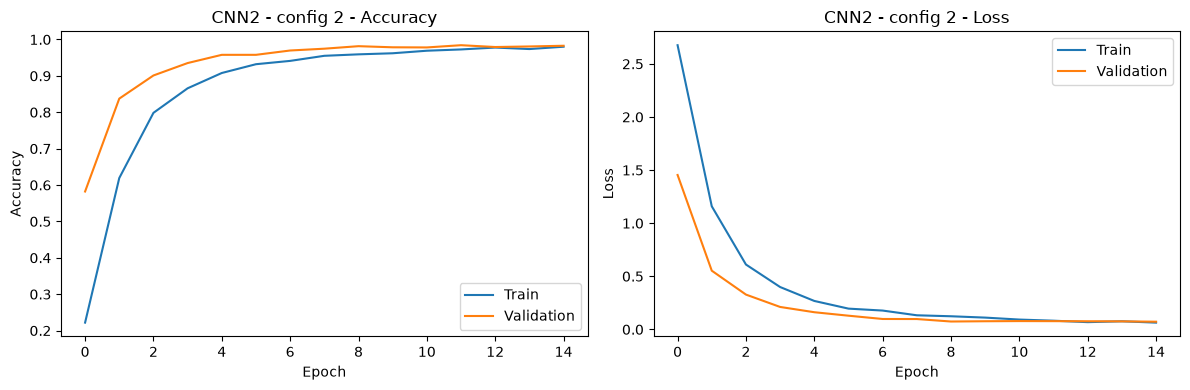

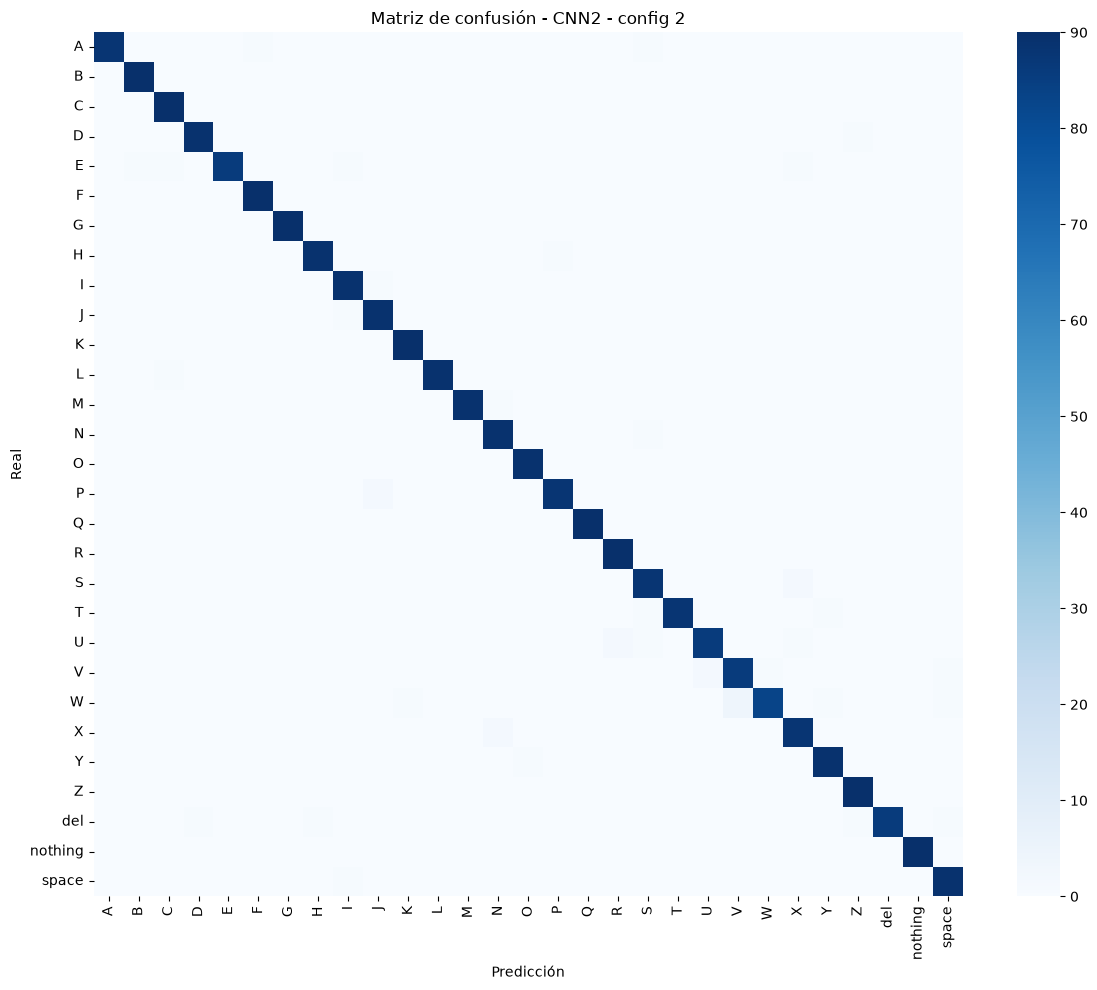


Reporte de clasificación - CNN2 - config 2
              precision    recall  f1-score   support

           A       1.00      0.98      0.99        90
           B       0.99      1.00      0.99        90
           C       0.98      1.00      0.99        90
           D       0.99      0.99      0.99        90
           E       1.00      0.96      0.98        90
           F       0.99      1.00      0.99        90
           G       1.00      1.00      1.00        90
           H       0.99      0.99      0.99        90
           I       0.97      0.99      0.98        90
           J       0.97      0.99      0.98        90
           K       0.99      1.00      0.99        90
           L       1.00      0.99      0.99        90
           M       1.00      0.99      0.99        90
           N       0.97      0.99      0.98        90
           O       0.99      1.00      0.99        89
           P       0.99      0.98      0.98        90
           Q       1.00      1.00    

In [ ]:

# EJERCICIO 4 - CNN #2: arquitectura más profunda
# (más capas, más filtros, dropout distinto, LR distinto)
 
def construir_cnn2(input_shape, num_clases, dropout=0.4, learning_rate=0.0005):
    modelo = models.Sequential([
        layers.Input(shape=input_shape),
 
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
 
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
 
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
 
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_clases, activation="softmax"),
    ], name="CNN2_profunda")
 
    modelo.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return modelo
 
 
#  Variaciones de hiperparámetros para CNN2 
#un pequeño gridsearch para incluso mejorar aún más el segundo CNN

configuraciones_cnn2 = [
    {"dropout": 0.4, "learning_rate": 0.0005, "batch_size": 32, "epochs": 15},
    {"dropout": 0.5, "learning_rate": 0.001,  "batch_size": 64, "epochs": 15},
]
 
resultados_cnn2 = []
for i, config in enumerate(configuraciones_cnn2, start=1):
    print(f"\n--- CNN2, configuración {i}: {config} ---")
    modelo_temp = construir_cnn2(
        INPUT_SHAPE, NUM_CLASES,
        dropout=config["dropout"],
        learning_rate=config["learning_rate"]
    )
    resultado_temp = entrenar_y_evaluar(
        modelo_temp, f"CNN2 - config {i}",
        X_train, y_train, X_val, y_val, X_test, y_test,
        epochs=config["epochs"], batch_size=config["batch_size"]
    )
    resultados_cnn2.append(resultado_temp)
 
# se queda la mejor configuración de CNN2 según accuracy de validación
resultado_cnn2 = max(resultados_cnn2, key=lambda r: r["val_accuracy"])
print(f"\nMejor configuración de CNN2: {resultado_cnn2['nombre']} "
      f"(val_accuracy={resultado_cnn2['val_accuracy']:.4f})")
 



Tabla comparativa de modelos:
                  Modelo  Parámetros  Epochs  Batch size  Tiempo entrenamiento (s)  Val Accuracy  Val Loss  Test Accuracy  Test Loss
Red Neuronal Simple (FC)     6430749      15          32                     117.5        0.0786    3.0701         0.0770     3.0783
            CNN 1 (base)     2120413      15          32                     105.2        0.9295    0.2402         0.9237     0.2561
         CNN2 - config 2     2244285      15          64                     338.9        0.9828    0.0724         0.9839     0.0554


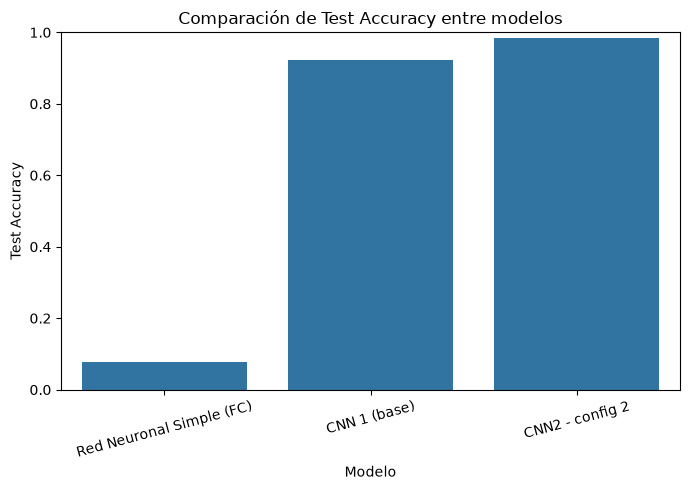


Mejor modelo general: CNN2 - config 2 con Test Accuracy = 0.9839
Mejor CNN: CNN2 - config 2 con Test Accuracy = 0.9839

Comparación CNN vs. Red Simple:
  Mejor CNN (CNN2 - config 2): 0.9839
  Red Simple (FC): 0.0770
  Diferencia (CNN - FC): +0.9069


In [ ]:

# Comparación de los 3 modelos

tabla_comparacion = pd.DataFrame([
    {
        "Modelo": r["nombre"],
        "Parámetros": r["num_parametros"],
        "Epochs": r["epochs"],
        "Batch size": r["batch_size"],
        "Tiempo entrenamiento (s)": round(r["tiempo_entrenamiento_seg"], 1),
        "Val Accuracy": round(r["val_accuracy"], 4),
        "Val Loss": round(r["val_loss"], 4),
        "Test Accuracy": round(r["test_accuracy"], 4),
        "Test Loss": round(r["test_loss"], 4),
    }
    for r in [resultado_fc, resultado_cnn1, resultado_cnn2]
])
 
print("\n\nTabla comparativa de modelos:")
print(tabla_comparacion.to_string(index=False))
 
# Gráfico comparativo de accuracy de test
plt.figure(figsize=(7, 5))
sns.barplot(data=tabla_comparacion, x="Modelo", y="Test Accuracy")
plt.title("Comparación de Test Accuracy entre modelos")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
 
# Selección del mejor modelo entre los 3 (FC, CNN1, CNN2)
mejor_general = max([resultado_fc, resultado_cnn1, resultado_cnn2], key=lambda r: r["test_accuracy"])
print(f"\nMejor modelo general: {mejor_general['nombre']} "
      f"con Test Accuracy = {mejor_general['test_accuracy']:.4f}")
 
#selección del mejor modelo entre las CNN (igual que el anterior jaja):
mejor_cnn = max([resultado_cnn1, resultado_cnn2], key=lambda r: r["test_accuracy"])
print(f"Mejor CNN: {mejor_cnn['nombre']} con Test Accuracy = {mejor_cnn['test_accuracy']:.4f}")
 
print(f"\nComparación CNN vs. Red Simple:")
print(f"  Mejor CNN ({mejor_cnn['nombre']}): {mejor_cnn['test_accuracy']:.4f}")
print(f"  Red Simple (FC): {resultado_fc['test_accuracy']:.4f}")
diferencia = mejor_cnn['test_accuracy'] - resultado_fc['test_accuracy']
print(f"  Diferencia (CNN - FC): {diferencia:+.4f}")